# Modeling

## Part 0: Importing Libraries

In [1]:
import os
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

import random
import io

c:\Users\fatah.rahimi\Desktop\Models\my_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.6.0+cu124
True
NVIDIA GeForce RTX 3060


## Part 1: Data Preprocessing

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [4]:
data_root ="../processed_ffpp"
print(os.listdir(data_root))

['test', 'train', 'val']


In [5]:
class RandomJPEGCompression:
    def __init__(self, quality_range=(25, 70), p=0.5):
        self.quality_range = quality_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        buffer = io.BytesIO()
        quality = random.randint(*self.quality_range)
        img.save(buffer, format="JPEG", quality=quality)
        buffer.seek(0)
        return Image.open(buffer).convert("RGB")

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    RandomJPEGCompression(quality_range=(25, 70), p=0.5),  # compression robustness
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
class VideoFrameDataset(Dataset):
    """
    One sample = one video folder containing multiple frame images.
    Returns:
        frames_tensor: shape (T, C, H, W)
        label: 0 for fake, 1 for real
    """

    IMG_EXTS = (".jpg", ".jpeg", ".png")

    def __init__(self, root_dir, transform=None, num_frames=8, mode="uniform"):
        self.root_dir = root_dir
        self.transform = transform
        self.num_frames = num_frames
        self.mode = mode  # "uniform" or "random"

        self.classes = ["fake", "real"]
        self.class_to_idx = {"fake": 0, "real": 1}
        self.samples = []

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue

            for video_name in sorted(os.listdir(class_dir)):
                video_dir = os.path.join(class_dir, video_name)
                if not os.path.isdir(video_dir):
                    continue

                frame_files = sorted([
                    os.path.join(video_dir, f)
                    for f in os.listdir(video_dir)
                    if f.lower().endswith(self.IMG_EXTS)
                ])

                if len(frame_files) == 0:
                    continue

                self.samples.append((frame_files, self.class_to_idx[class_name], video_dir))

        print(f"[{root_dir}] Found {len(self.samples)} videos.")

    def __len__(self):
        return len(self.samples)

    def _sample_indices(self, n_frames):
        if n_frames >= self.num_frames:
            if self.mode == "random":
                indices = sorted(random.sample(range(n_frames), self.num_frames))
            else:
                indices = np.linspace(0, n_frames - 1, self.num_frames, dtype=int).tolist()
        else:
            # Repeat frames if video has fewer than num_frames
            indices = np.linspace(0, n_frames - 1, self.num_frames, dtype=int).tolist()

        return indices

    def __getitem__(self, idx):
        frame_files, label, video_dir = self.samples[idx]
        indices = self._sample_indices(len(frame_files))

        frames = []
        for i in indices:
            img_path = frame_files[i]
            img = Image.open(img_path).convert("RGB")

            if self.transform is not None:
                img = self.transform(img)

            frames.append(img)

        frames = torch.stack(frames, dim=0)  # (T, C, H, W)
        return frames, torch.tensor(label, dtype=torch.float32)

In [12]:
NUM_FRAMES = 8
BATCH_SIZE = 4  # lower than frame model because sequence model uses more memory

train_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "train"),
    transform=train_transform,
    num_frames=NUM_FRAMES,
    mode="random" # uniform
)

val_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "val"),
    transform=val_test_transform,
    num_frames=NUM_FRAMES,
    mode="uniform"
)

test_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "test"),
    transform=val_test_transform,
    num_frames=NUM_FRAMES,
    mode="uniform"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

[../processed_ffpp\train] Found 280 videos.
[../processed_ffpp\val] Found 60 videos.
[../processed_ffpp\test] Found 60 videos.


In [9]:
videos, labels = next(iter(train_loader))
print("Video batch shape:", videos.shape)   # (B, T, C, H, W)
print("Labels shape:", labels.shape)

Video batch shape: torch.Size([4, 8, 3, 224, 224])
Labels shape: torch.Size([4])


## Part 2: Build and Fit the Model

In [13]:
import torch
import torch.nn as nn
import timm


class CNN_ViT_BiLSTM(nn.Module):

    def __init__(
        self,
        cnn_model='efficientnet_b0',
        vit_model='deit_tiny_patch16_224',
        proj_dim=128,
        lstm_hidden=128,
        lstm_layers=1,
        dropout=0.4194,
        freeze_cnn=True,
        freeze_vit=True
    ):
        super().__init__()

        # =====================================================
        # CNN Backbone
        # =====================================================

        self.cnn = timm.create_model(
            cnn_model,
            pretrained=True
        )

        self.cnn.reset_classifier(0)

        # =====================================================
        # ViT Backbone
        # =====================================================

        self.vit = timm.create_model(
            vit_model,
            pretrained=True
        )

        self.vit.reset_classifier(0)

        # =====================================================
        # Automatic Feature Dimension Inference
        # =====================================================

        with torch.no_grad():

            dummy = torch.randn(1, 3, 224, 224)

            cnn_out = self.cnn(dummy)
            cnn_feature_dim = cnn_out.shape[1]

            vit_out = self.vit(dummy)
            vit_feature_dim = vit_out.shape[1]

        # =====================================================
        # Freeze Backbones
        # =====================================================

        if freeze_cnn:
            for param in self.cnn.parameters():
                param.requires_grad = False

        if freeze_vit:
            for param in self.vit.parameters():
                param.requires_grad = False

        # =====================================================
        # Projection Layers
        # =====================================================

        self.cnn_proj = nn.Sequential(
            nn.Linear(cnn_feature_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.vit_proj = nn.Sequential(
            nn.Linear(vit_feature_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # =====================================================
        # Fusion
        # =====================================================

        self.fusion_norm = nn.LayerNorm(proj_dim * 2)

        # =====================================================
        # Temporal Modeling
        # =====================================================

        self.lstm = nn.LSTM(
            input_size=proj_dim * 2,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.0 if lstm_layers == 1 else dropout
        )

        # =====================================================
        # Classification Head
        # =====================================================

        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 1)
        )

    def forward(self, x):

        # =====================================================
        # Input Shape
        # x -> (B, T, C, H, W)
        # =====================================================

        B, T, C, H, W = x.shape

        x = x.view(B * T, C, H, W)

        # =====================================================
        # CNN Features
        # =====================================================

        cnn_feat = self.cnn(x)

        # =====================================================
        # ViT Features
        # =====================================================

        vit_feat = self.vit(x)

        # =====================================================
        # Projection
        # =====================================================

        cnn_feat = self.cnn_proj(cnn_feat)

        vit_feat = self.vit_proj(vit_feat)

        # =====================================================
        # Fusion
        # =====================================================

        fused = torch.cat(
            [cnn_feat, vit_feat],
            dim=1
        )

        fused = self.fusion_norm(fused)

        # =====================================================
        # Sequence Reshape
        # =====================================================

        seq_feat = fused.view(B, T, -1)

        # =====================================================
        # BiLSTM
        # =====================================================

        lstm_out, _ = self.lstm(seq_feat)

        # =====================================================
        # Temporal Pooling
        # =====================================================

        temporal_feat = lstm_out.mean(dim=1)

        # =====================================================
        # Classification
        # =====================================================

        out = self.classifier(temporal_feat)

        return out

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_ViT_BiLSTM().to(device)

In [15]:

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW([

    # Classification head
    {
        "params": model.classifier.parameters(),
        "lr": 3e-4
    },

    # Temporal module
    {
        "params": model.lstm.parameters(),
        "lr": 3e-4
    },

    # Projection layers
    {
        "params": model.cnn_proj.parameters(),
        "lr": 3e-4
    },

    {
        "params": model.vit_proj.parameters(),
        "lr": 3e-4
    },

    # Pretrained CNN backbone
    {
        "params": model.cnn.parameters(),
        "lr": 3e-5
    },

    # Pretrained ViT backbone
    {
        "params": model.vit.parameters(),
        "lr": 3e-5
    },

], weight_decay=1e-5)


In [16]:
# =========================================================
# Scheduler
# =========================================================
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,
    verbose=True
)

c:\Users\fatah.rahimi\Desktop\Models\my_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [17]:

print(device)

cuda


In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for videos, labels in tqdm(loader, desc="Training"):
        videos = videos.to(device)
        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_labels.extend(labels.cpu().numpy().ravel())
        all_preds.extend(preds.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for videos, labels in tqdm(loader, desc="Validation"):
            videos = videos.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(videos)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_labels.extend(labels.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)
    epoch_auc = roc_auc_score(all_labels, all_probs)

    return epoch_loss, epoch_acc, epoch_f1, epoch_auc

In [24]:
# import wandb

In [25]:
# wandb.login(key= "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")

In [26]:
# wandb.init(project = "model_1",id="silvery-grass-1",resume="allow")

In [27]:
# wandb.watch(model)

In [19]:
checkpoint_path = "video_checkpoint.pth"
model_path = "video_model.pth"

epochs = 50
patience = 10
counter = 0
best_val_f1 = 0.0
start_epoch = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_f1s, val_f1s = [], []
val_aucs = []


# =========================================================
# Load checkpoint safely
# =========================================================
if os.path.exists(checkpoint_path):

    print("Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Load model weights
    model.load_state_dict(checkpoint["model_state_dict"])

    # Load optimizer safely
    try:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        print("Optimizer restored successfully")

    except ValueError:
        print("Optimizer structure changed -> using fresh optimizer")

    # Restore training state
    start_epoch = checkpoint["epoch"] + 1
    best_val_f1 = checkpoint.get("best_val_f1", 0.0)
    counter = checkpoint.get("counter", 0)

    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])

    train_accuracies = checkpoint.get("train_accuracies", [])
    val_accuracies = checkpoint.get("val_accuracies", [])

    train_f1s = checkpoint.get("train_f1s", [])
    val_f1s = checkpoint.get("val_f1s", [])

    val_aucs = checkpoint.get("val_aucs", [])

    print(f"Resuming from epoch {start_epoch}")

# =========================================================
# Training Loop
# =========================================================
for epoch in range(start_epoch, epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    # =====================================================
    # Unfreeze at epoch 8
    # =====================================================
    if epoch == 8:

        print("🔓 Unfreezing CNN + ViT")

        for param in model.cnn.parameters():
            param.requires_grad = True

        for param in model.vit.parameters():
            param.requires_grad = True

        

    # =====================================================
    # Train
    # =====================================================
    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # =====================================================
    # Validation
    # =====================================================
    val_loss, val_acc, val_f1, val_auc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    # =====================================================
    # Scheduler Step
    # =====================================================
    scheduler.step(val_f1)

    # =====================================================
    # Save Metrics
    # =====================================================
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    val_aucs.append(val_auc)

    # =====================================================
    # Print Results
    # =====================================================
    print(
        f"Train Loss={train_loss:.4f}, "
        f"Train Acc={train_acc:.4f}, "
        f"Train F1={train_f1:.4f} | "
        f"Val Loss={val_loss:.4f}, "
        f"Val Acc={val_acc:.4f}, "
        f"Val F1={val_f1:.4f}, "
        f"Val AUC={val_auc:.4f}"
    )

    torch.save(model.state_dict(), model_path)
    # =====================================================
    # Save Checkpoint
    # =====================================================
    torch.save({

        "epoch": epoch,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),

        "best_val_f1": best_val_f1,

        "counter": counter,

        "train_losses": train_losses,
        "val_losses": val_losses,

        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,

        "train_f1s": train_f1s,
        "val_f1s": val_f1s,

        "val_aucs": val_aucs

    }, checkpoint_path)

    # =====================================================
    # WandB Logging
    # =====================================================
#     wandb.log({

#     "Accuracy/Train": train_acc,
#     "Accuracy/Validation": val_acc,

#     "Loss/Train": train_loss,
#     "Loss/Validation": val_loss,

#     "F1/Train": train_f1,
#     "F1/Validation": val_f1,

#     "AUC/Validation": val_auc

# }, step=epoch)
    # =====================================================
    # Early Stopping
    # =====================================================
    if counter >= patience:

        print("⛔ Early stopping triggered")
        break

# =========================================================
# Finish WandB
# =========================================================
# wandb.finish()


Epoch 1/50


Validation: 100%|██████████| 15/15 [00:01<00:00, 10.88it/s]


Train Loss=0.6844, Train Acc=0.5536, Train F1=0.6154 | Val Loss=0.6017, Val Acc=0.7333, Val F1=0.6923, Val AUC=0.8322

Epoch 2/50


Validation: 100%|██████████| 15/15 [00:01<00:00, 11.25it/s]


Train Loss=0.6390, Train Acc=0.6536, Train F1=0.6447 | Val Loss=0.5107, Val Acc=0.8000, Val F1=0.7778, Val AUC=0.8567

Epoch 3/50


...

Train Loss=0.1293, Train Acc=0.9464, Train F1=0.9451 | Val Loss=0.2350, Val Acc=0.9167, Val F1=0.9123, Val AUC=0.9744

Epoch 49/50


Validation: 100%|██████████| 15/15 [00:01<00:00, 12.09it/s]


Train Loss=0.1304, Train Acc=0.9500, Train F1=0.9504 | Val Loss=0.2491, Val Acc=0.9167, Val F1=0.9123, Val AUC=0.9767

Epoch 50/50


Validation: 100%|██████████| 15/15 [00:01<00:00, 12.10it/s]


Train Loss=0.1282, Train Acc=0.9500, Train F1=0.9496 | Val Loss=0.2491, Val Acc=0.9167, Val F1=0.9123, Val AUC=0.9756


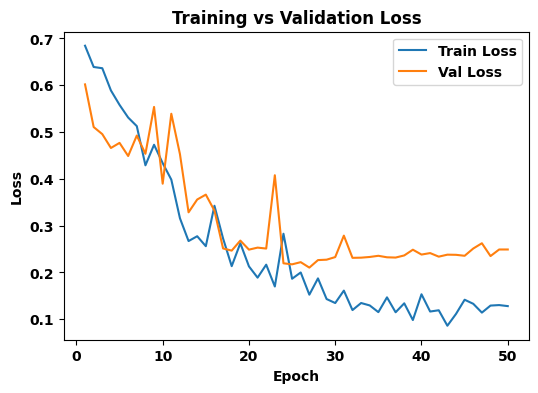

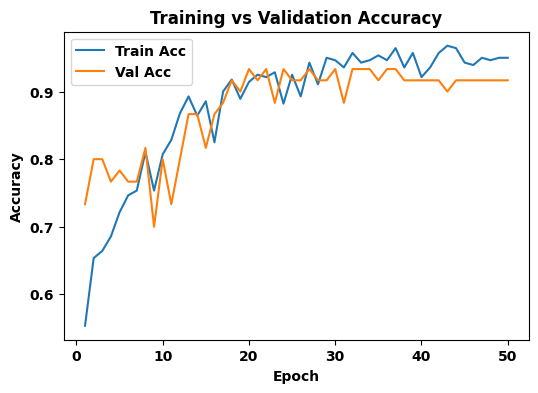

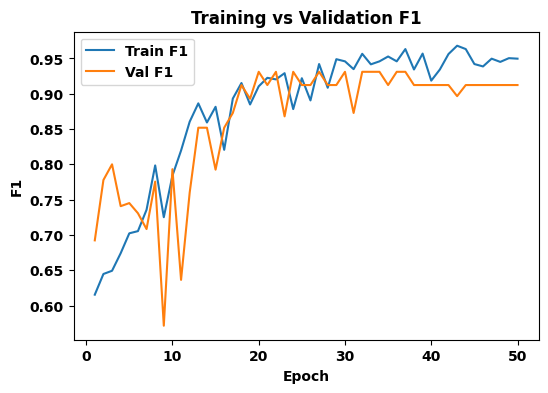

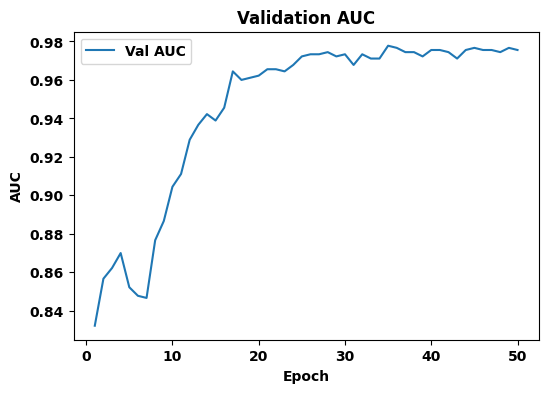

In [20]:
# Set global bold style for most text elements
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.handlelength'] = 2

def bold_tick_labels():
    """Make tick labels bold for the current figure"""
    ax = plt.gca()
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

epochs_range = range(1, len(train_losses) + 1)

# Figure 1: Loss
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
bold_tick_labels()
plt.show()

# Figure 2: Accuracy
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_accuracies, label="Train Acc")
plt.plot(epochs_range, val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
bold_tick_labels()
plt.show()

# Figure 3: F1 Score
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_f1s, label="Train F1")
plt.plot(epochs_range, val_f1s, label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Training vs Validation F1")
plt.legend()
bold_tick_labels()
plt.show()

# Figure 4: Validation AUC
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, val_aucs, label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Validation AUC")
plt.legend()
bold_tick_labels()
plt.show()

## Part 3: Evaluate the Model

In [ ]:
#best_model_path = "/content/drive/MyDrive/XST-Deepfake-Detection/new_version/video_best_model.pth"

In [21]:
model.load_state_dict(torch.load(model_path, map_location=device))

<All keys matched successfully>

In [22]:
def test_model(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for videos, labels in tqdm(loader, desc="Testing"):
            videos = videos.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(videos)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_labels.extend(labels.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1-score: {f1:.4f}")
    print(f"Test AUC: {auc:.4f}")

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [23]:
all_labels, all_preds, all_probs = test_model(model, test_loader, device)

Testing: 100%|██████████| 15/15 [00:01<00:00, 11.29it/s]

Test Accuracy: 0.9167
Test F1-score: 0.9153
Test AUC: 0.9544


              precision    recall  f1-score   support

        fake       0.90      0.93      0.92        30
        real       0.93      0.90      0.92        30

    accuracy                           0.92        60
   macro avg       0.92      0.92      0.92        60
weighted avg       0.92      0.92      0.92        60

Confusion Matrix:
 [[28  2]
 [ 3 27]]


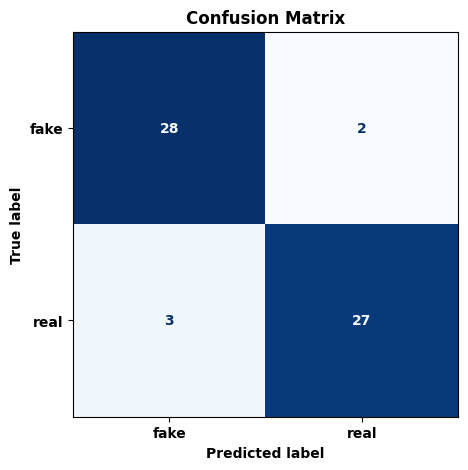

In [24]:
target_names = ["fake", "real"]

print(classification_report(
    all_labels.astype(int),
    all_preds.astype(int),
    target_names=target_names
))

cm = confusion_matrix(all_labels.astype(int), all_preds.astype(int))
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap="Blues", colorbar=False, ax=ax)
plt.title("Confusion Matrix")
plt.show()